In [1]:
import os
import glob
import pandas as pd

In [13]:
# --- CONFIGURE THIS ---
input_csv_folder = r"C:\Users\chris\Desktop\University\Thesis\PipelineResults\10_patients_GM_tiles"
# ----------------------

csv_files = glob.glob(os.path.join(input_csv_folder, "pipeline_run_*.csv"))

dfs = []
for path in csv_files:
    temp_df = pd.read_csv(path)
    temp_df = temp_df.rename(columns={"scan_folder": "scan_name"})
    dfs.append(temp_df)

df = pd.concat(dfs, ignore_index=True)

features = [
    "skeleton_length",
    "num_junctions",
    "num_components",
    "num_end_nodes",
    "num_start_nodes",
    "total_nodes",
    "end_to_start_ratio",
    "soma_area",
    "soma_perimeter",
    "soma_circularity",
    "cell_area",
    "cell_perimeter",
    "cell_convex_hull_area",
    "cell_convex_hull_perimeter",
    "cell_solidity",
    "cell_convexity",
    "cell_circularity",
    "cell_convex_circularity",
    "branch_area",
    "branch_perimeter",
    "sholl_min_radius",
    "sholl_peak_radius",
    "sholl_max_radius",
    "sholl_peak",
    "sholl_sum",
]

print(f"Number of cells in analysis {len(df)}")

Number of cells in analysis 156589


Remove Outliers based on cell_area

In [14]:
lower = df["cell_area"].quantile(0.002)
upper = df["cell_area"].quantile(0.998)

df = df[
    (df["cell_area"] >= lower) &
    (df["cell_area"] <= upper)
].copy()

print(f"Removed very small or very large cells")

print(f"Number of cells in analysis {len(df)}")

Removed very small or very large cells
Number of cells in analysis 155963


Remove cells that touch the image border (not fully contained in the tile)

In [ ]:
# Tiles are 512x512 pixels.
# A cell whose bounding box touches any edge of the tile was clipped and
# therefore not fully visible. We remove any cell where:
#   xmin == 0  (touches left edge)
#   ymin == 0  (touches top edge)
#   xmax >= TILE_SIZE - 1  (touches right edge)
#   ymax >= TILE_SIZE - 1  (touches bottom edge)

TILE_SIZE = 512

before = len(df)

df = df[
    (df["xmin"] > 0) &
    (df["ymin"] > 0) &
    (df["xmax"] < TILE_SIZE - 1) &
    (df["ymax"] < TILE_SIZE - 1)
].copy()

print(f"Removed {before - len(df)} border-clipped cells ({before} -> {len(df)})")


Histogram of all features

C:\Users\chris\AppData\Local\Temp\ipykernel_21148\4144483297.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


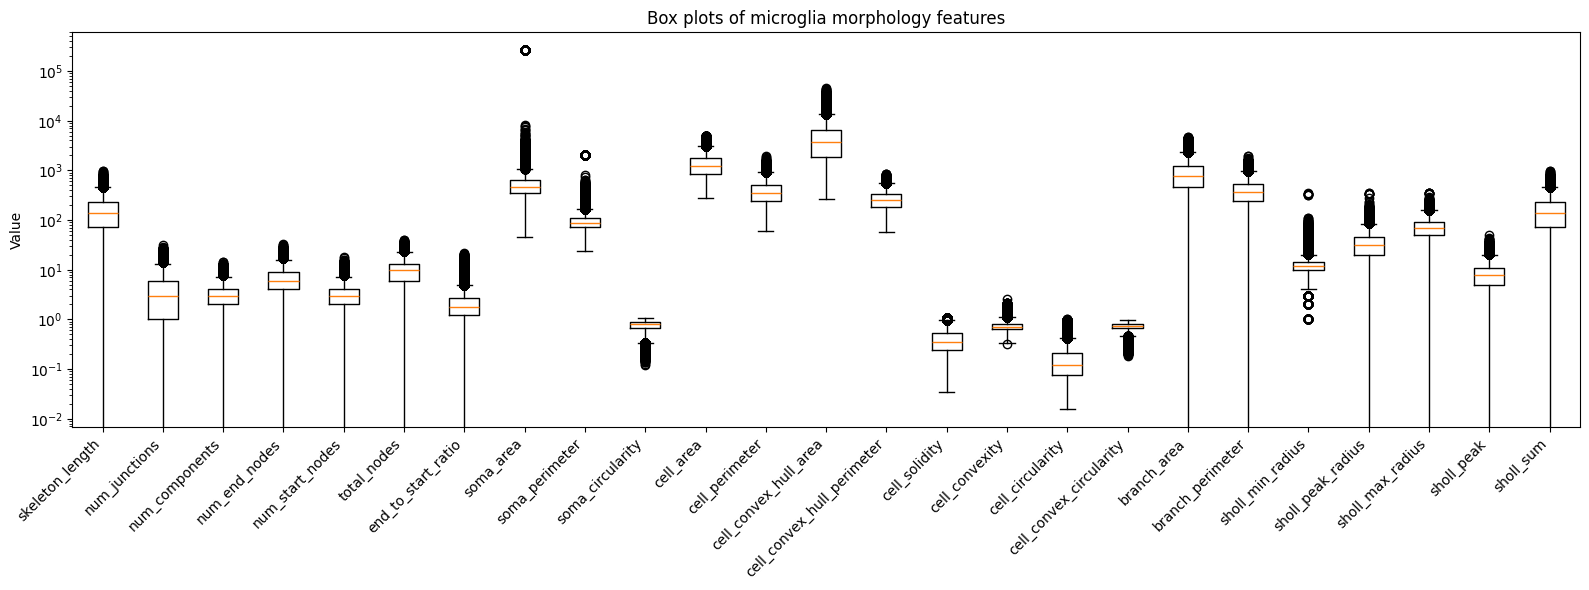

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))
plt.boxplot(
    [df[f].dropna() for f in features],
    labels=features,
    vert=True
)
plt.yscale("log")


plt.xticks(rotation=45, ha="right")
plt.ylabel("Value")
plt.title("Box plots of microglia morphology features")
plt.tight_layout()
plt.show()


Histogram of a selected feature

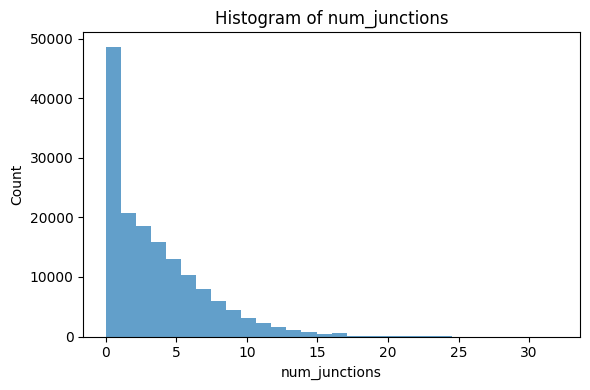

In [17]:
import matplotlib.pyplot as plt

feature = "num_junctions"

plt.figure(figsize=(6, 4))
plt.hist(df[feature].dropna(), bins=30, alpha=0.7)
plt.xlabel(feature)
plt.ylabel("Count")
plt.title(f"Histogram of {feature}")
plt.tight_layout()
plt.show()


Scatter plot of 2 features

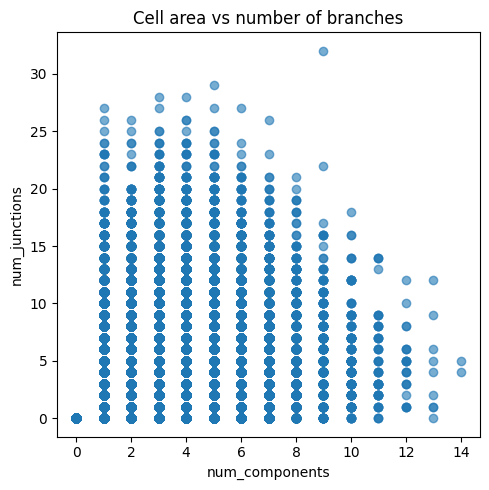

In [19]:
feature_x = "num_components"
feature_y = 'num_junctions'

plt.figure(figsize=(5, 5))
plt.scatter(
    df[feature_x],
    df[feature_y],
    alpha=0.6
)
# plt.yscale('log')
# plt.xscale('log')

plt.xlabel(feature_x)
plt.ylabel(feature_y)
plt.title("Cell area vs number of branches")
plt.tight_layout()
plt.show()


Correlation Matrix

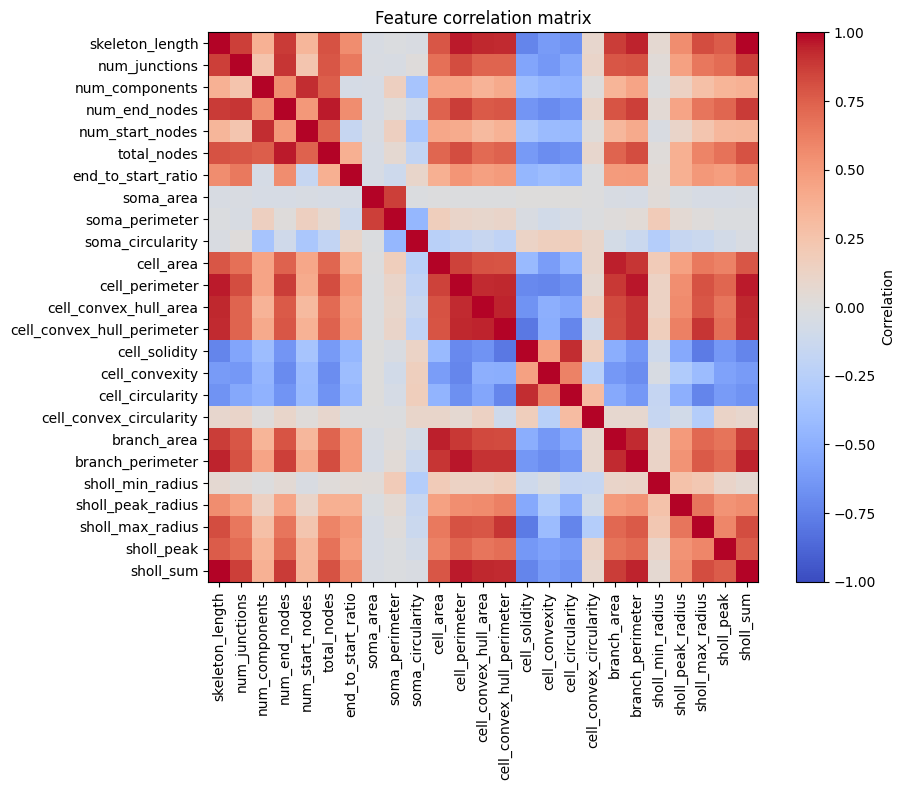

In [20]:
corr = df[features].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(features)), features, rotation=90)
plt.yticks(range(len(features)), features)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()


PCA Plot

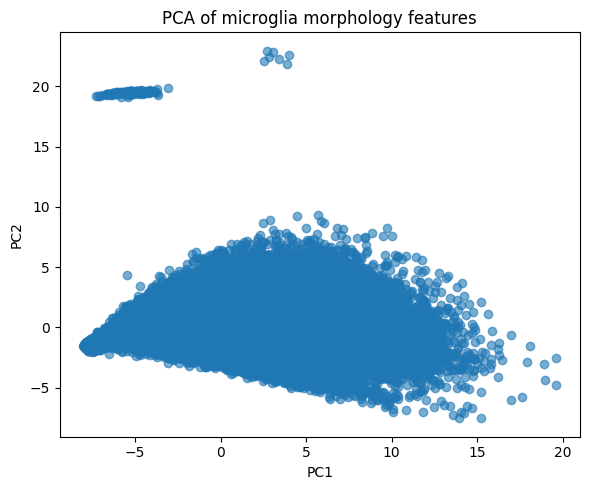

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df[features].dropna()
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of microglia morphology features")
plt.tight_layout()
plt.show()


Basic Clustering

In [23]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans

# Hierarchical clustering into 4 clusters
# clusterer = AgglomerativeClustering(
#     n_clusters=5,
#     linkage="ward"
# )

clusterer = KMeans(
    n_clusters=4,
    n_init=50,
    random_state=42
)


cluster_labels = clusterer.fit_predict(X_scaled)
df_clustered = df.loc[X.index].copy()
df_clustered["cluster"] = cluster_labels



In [24]:
import cv2
import matplotlib.pyplot as plt

def show_yolo_box(image_path, box, color=(0, 0, 255), linewidth=2):
    """
    Display an image with a YOLO bounding box overlaid.

    Parameters
    ----------
    image_path : str
        Path to the image file.
    box : tuple
        (x_min, y_min, x_max, y_max) in pixel coordinates.
    color : tuple
        RGB color for the box.
    linewidth : int
        Line thickness.
    """
    # Read image (BGR)
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Could not read image: {image_path}")

    # Convert to RGB for matplotlib
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    x_min, y_min, x_max, y_max = map(int, box)

    # Draw rectangle
    cv2.rectangle(
        image_rgb,
        (x_min, y_min),
        (x_max, y_max),
        color,
        linewidth
    )

    # Show image
    plt.figure(figsize=(6, 6))
    plt.imshow(image_rgb)
    plt.axis("off")
    plt.title("YOLO bounding box")
    plt.show()

# x_min = 100
# y_min = 200
# x_max = 200
# y_max = 300

# show_yolo_box(
#     image_path="../../tiles/slide_2_test/tile_01424_x38912_y14336.jpg",
#     box=(x_min, y_min, x_max, y_max)
# )

Cluster 0: representative global_cell_id = tile_01826_x45056_y18432_cell_0 (distance = 0.876)


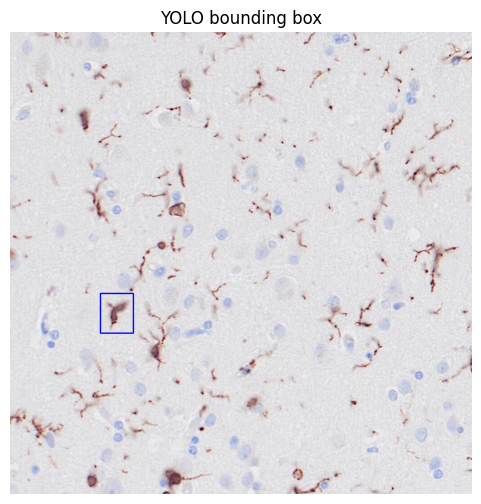

Cluster 1: representative global_cell_id = tile_01915_x34816_y19456_cell_1 (distance = 0.894)


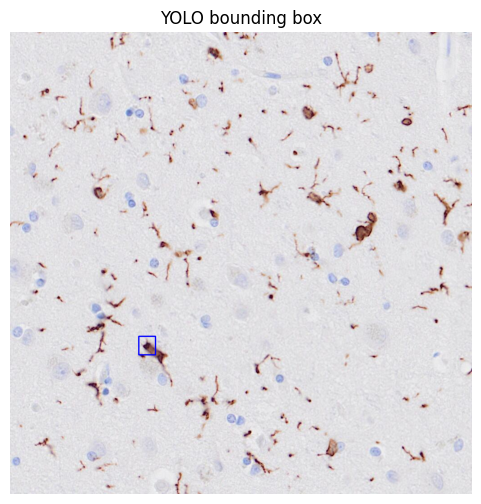

Cluster 2: representative global_cell_id = tile_01841_x60416_y18432_cell_5 (distance = 1.479)


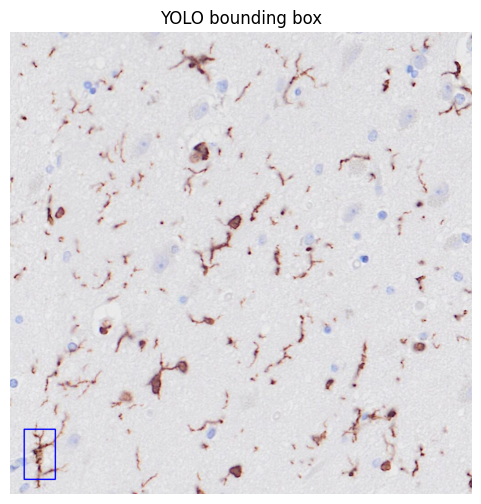

Cluster 3: representative global_cell_id = tile_01934_x54272_y19456_cell_1 (distance = 0.439)


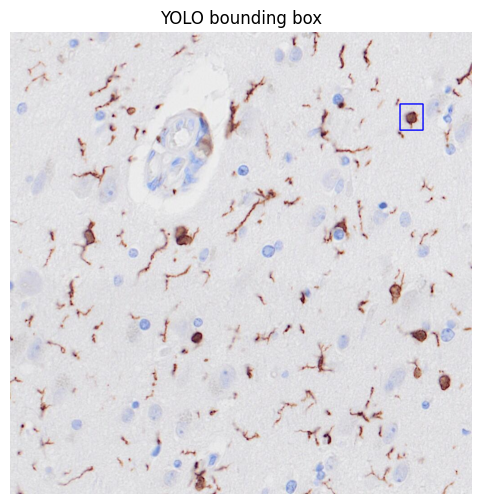

Cluster 4: representative global_cell_id = tile_01836_x55296_y18432_cell_5 (distance = 2.944)


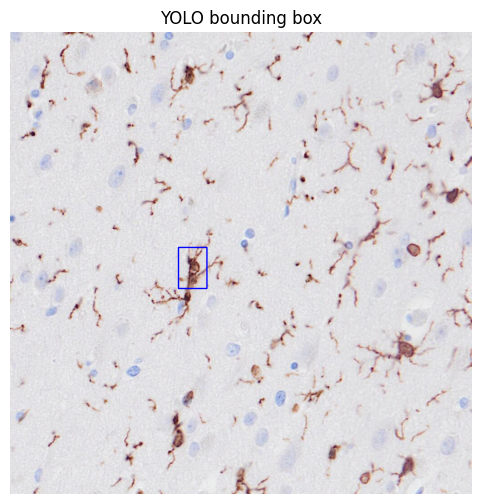

In [62]:
from scipy.spatial.distance import cdist

# --- CONFIGURE THIS ---
scan_data_root = r"C:\Users\chris\Desktop\University\Thesis\ScanData\10_patients_GM_tiles"
N_REPRESENTATIVES = 4  # number of most-central cells to show per cluster
# ----------------------

for cluster_id in sorted(df_clustered["cluster"].unique()):
    cluster_mask = df_clustered["cluster"] == cluster_id
    cluster_df = df_clustered[cluster_mask]

    # Feature vectors for this cluster
    X_cluster = X_scaled[cluster_mask.values]

    # Centroid
    centroid = X_cluster.mean(axis=0, keepdims=True)

    # Distance of every cell to the centroid
    distances = cdist(X_cluster, centroid, metric="euclidean").flatten()

    # Indices of the N closest cells (sorted nearest-first)
    closest_idxs = np.argsort(distances)[:N_REPRESENTATIVES]

    # Collect representative rows
    reps = []
    for idx in closest_idxs:
        global_index = cluster_df.iloc[idx].name
        reps.append({
            "global_cell_id": df.loc[global_index, "global_cell_id"],
            "distance_to_centroid": distances[idx],
            "scan_name": df.loc[global_index, "scan_name"],
            "image_name": df.loc[global_index, "image_name"],
            "xmin": df.loc[global_index, "xmin"],
            "ymin": df.loc[global_index, "ymin"],
            "xmax": df.loc[global_index, "xmax"],
            "ymax": df.loc[global_index, "ymax"],
        })

    # --- Plot all N representatives side-by-side in one figure ---
    n = len(reps)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 6))
    if n == 1:
        axes = [axes]
    fig.suptitle(f"Cluster {cluster_id} – {n} most central cells", fontsize=14)

    for ax, r in zip(axes, reps):
        image_path = os.path.join(scan_data_root, r["scan_name"], r["image_name"] + ".jpg")
        image = cv2.imread(image_path)
        if image is None:
            ax.set_title(f"NOT FOUND\n{r['image_name']}")
            ax.axis("off")
            continue
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        x_min, y_min, x_max, y_max = int(r["xmin"]), int(r["ymin"]), int(r["xmax"]), int(r["ymax"])
        cv2.rectangle(image_rgb, (x_min, y_min), (x_max, y_max), (0, 0, 255), 2)
        ax.imshow(image_rgb)
        ax.axis("off")
        ax.set_title(
            f"{r['global_cell_id']}\nd={r['distance_to_centroid']:.3f}",
            fontsize=7
        )

    plt.tight_layout()
    plt.show()


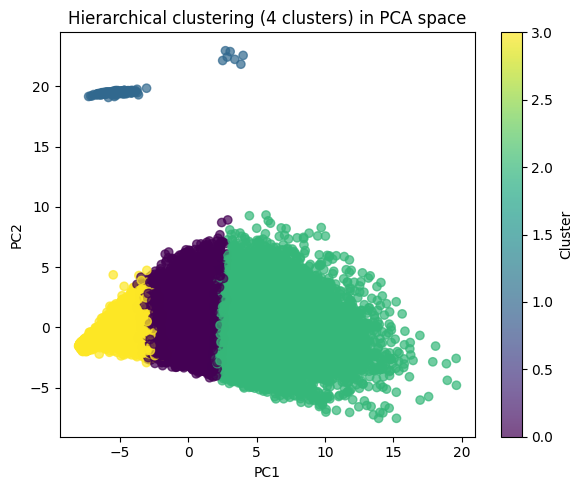

In [25]:
plt.figure(figsize=(6, 5))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    alpha=0.7
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Hierarchical clustering (4 clusters) in PCA space")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()


Show features per cluster

C:\Users\chris\AppData\Local\Temp\ipykernel_19080\3677029761.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


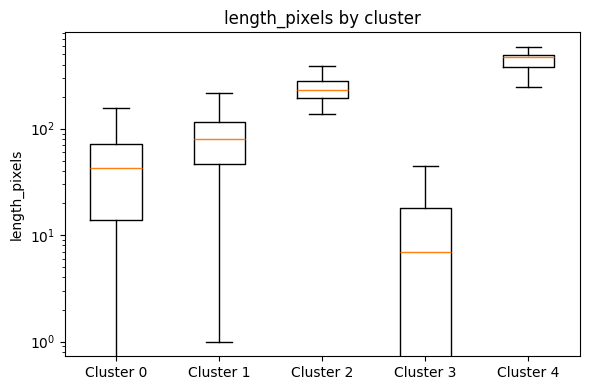

C:\Users\chris\AppData\Local\Temp\ipykernel_19080\3677029761.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


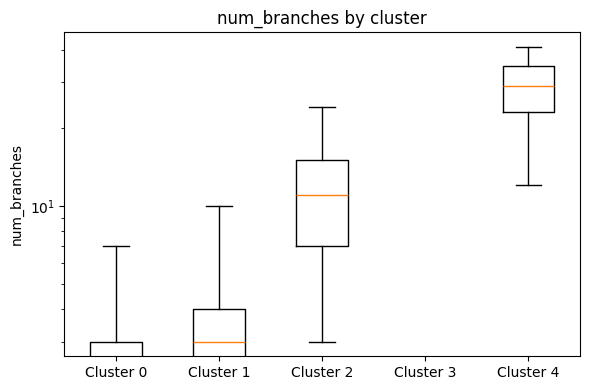

C:\Users\chris\AppData\Local\Temp\ipykernel_19080\3677029761.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


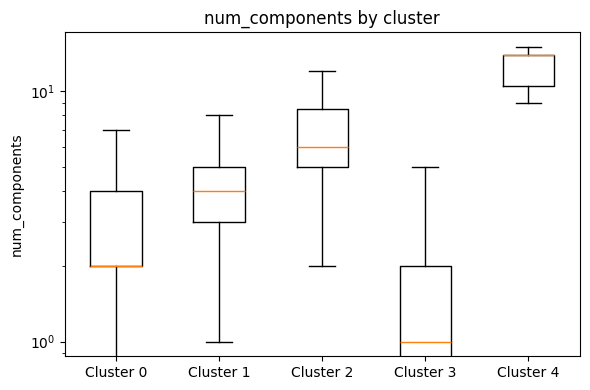

C:\Users\chris\AppData\Local\Temp\ipykernel_19080\3677029761.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


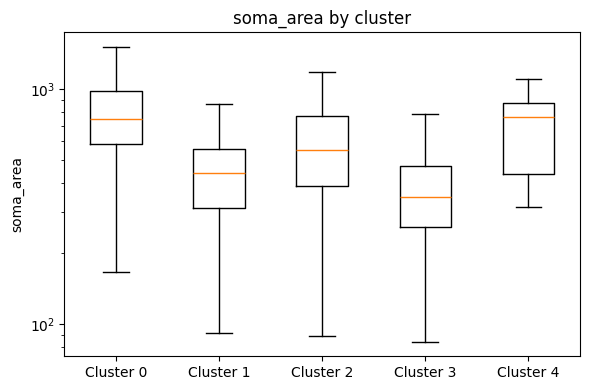

C:\Users\chris\AppData\Local\Temp\ipykernel_19080\3677029761.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


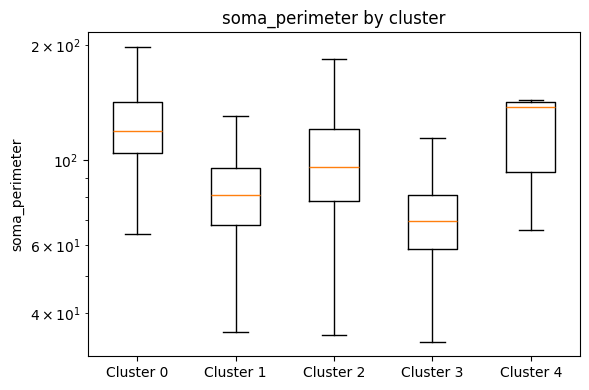

C:\Users\chris\AppData\Local\Temp\ipykernel_19080\3677029761.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


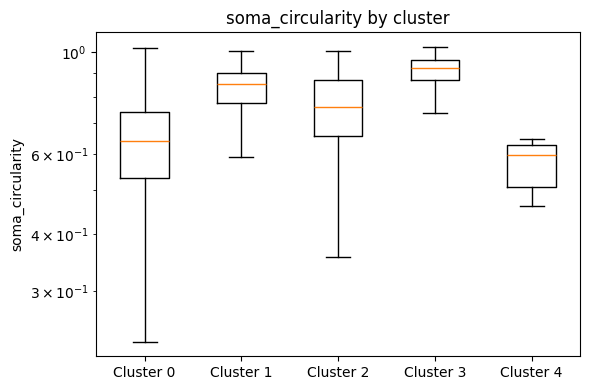

C:\Users\chris\AppData\Local\Temp\ipykernel_19080\3677029761.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


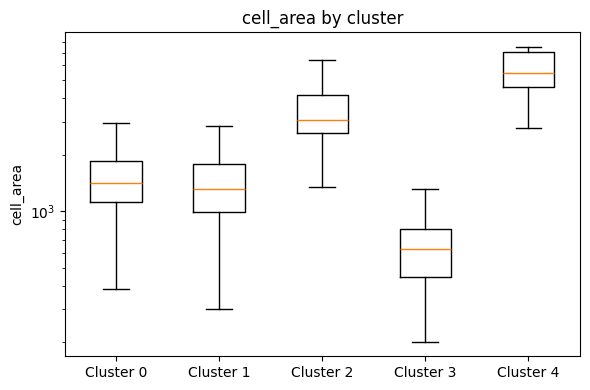

C:\Users\chris\AppData\Local\Temp\ipykernel_19080\3677029761.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


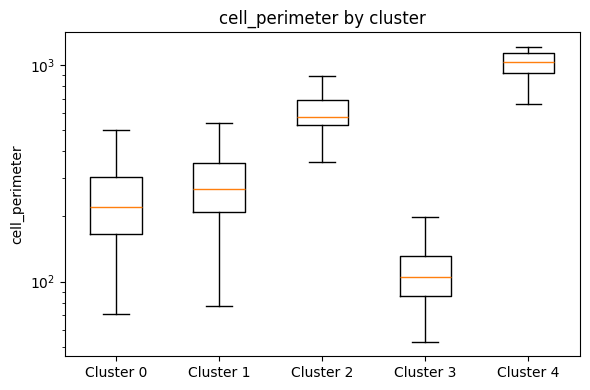

C:\Users\chris\AppData\Local\Temp\ipykernel_19080\3677029761.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


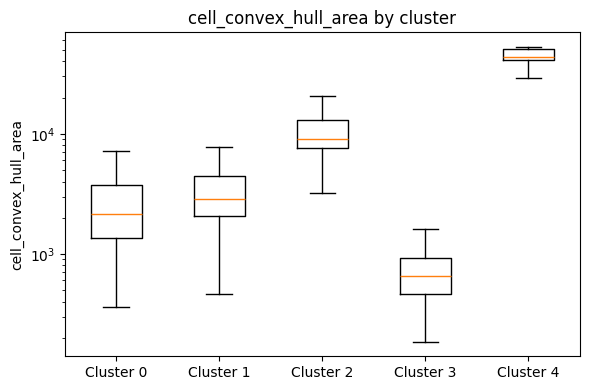

C:\Users\chris\AppData\Local\Temp\ipykernel_19080\3677029761.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


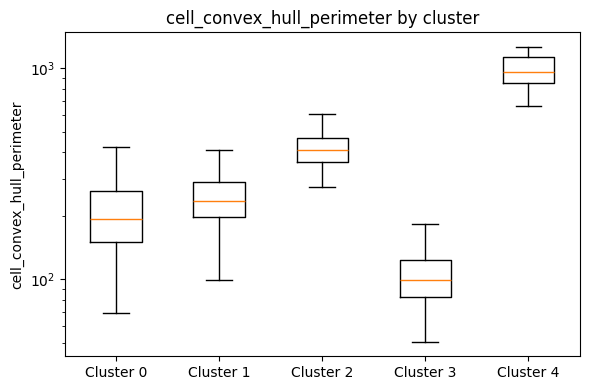

C:\Users\chris\AppData\Local\Temp\ipykernel_19080\3677029761.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


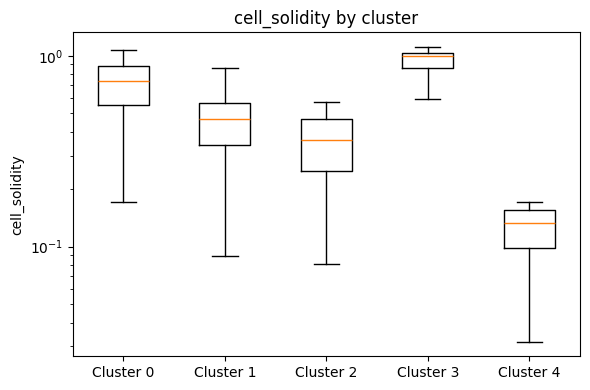

C:\Users\chris\AppData\Local\Temp\ipykernel_19080\3677029761.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


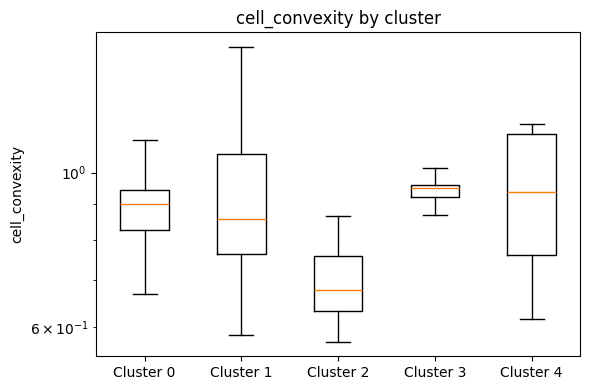

C:\Users\chris\AppData\Local\Temp\ipykernel_19080\3677029761.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


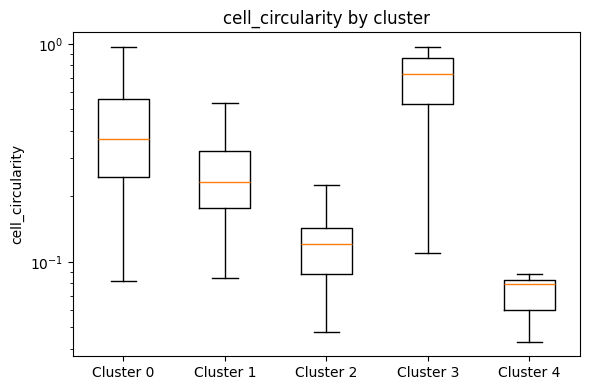

In [64]:
import matplotlib.pyplot as plt
import numpy as np

clusters = sorted(df_clustered["cluster"].unique())

for feature in features:
    plt.figure(figsize=(6, 4))

    data = [
        df_clustered[df_clustered["cluster"] == c][feature].dropna()
        for c in clusters
    ]

    plt.boxplot(
        data,
        labels=[f"Cluster {c}" for c in clusters],
        showfliers=False
    )

    plt.yscale("log")
    plt.ylabel(feature)
    plt.title(f"{feature} by cluster")
    plt.tight_layout()
    plt.show()
